# Vision transformer for image classification

In this lab you will familiarize yourself with the building blocks of the **transformer** architecture and build a vision transformer (ViT) model for classifying the [CIFAR-10](https://en.wikipedia.org/wiki/CIFAR-10) dataset.

Complete the code flagged throughout the notebook and **answer all questions** in the question blocks.

### Resources
- Attention intuition and theory (D2L): https://d2l.ai/chapter_attention-mechanisms-and-transformers/index.html
- Original transformer paper: [Attention Is All You Need](https://arxiv.org/abs/1706.03762)
- ViT paper: [An Image is Worth 16x16 Words](https://arxiv.org/abs/2010.11929)
- Additional implementation references:
  - https://www.kaggle.com/code/raufmomin/vision-transformer-vit-from-scratch/comments
  - https://www.kaggle.com/code/samuelnordmann/transformer-in-tensorflow-from-scratch/notebook
  - https://medium.com/towards-data-science/implementing-vision-transformer-vit-from-scratch-3e192c6155f0

## Imports, utilities and configurations (DO NOT MODIFY)
### Imports

In [1]:
import os
from dataclasses import dataclass
from pathlib import Path
from carbontracker.tracker import CarbonTracker

import matplotlib.pyplot as plt
import numpy as np

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
os.environ['TF_DISABLE_PLUGGABLE_DEVICE'] = '1'

TF_AVAILABLE = True
TF_IMPORT_ERROR = None

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except Exception as exc:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = exc
    print('TensorFlow could not be imported in this environment.')
    print(exc)

ROOT = Path.cwd()
print(f'Notebook root: {ROOT}')
print(f'TensorFlow available: {TF_AVAILABLE}')

2026-04-29 12:13:09.669263: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777457589.715714   19707 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777457589.727163   19707 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Notebook root: /home/alvaro-barbosa/Documents/Linkoping/732A82_Deep_Learning/deeplearninglabs/5_Transformers
TensorFlow available: True


### Check TensorFlow device (optional)

Training can be faster with a GPU, but this notebook is designed to work on CPU.

If a GPU is available and configured correctly, TensorFlow should report it below.

In [2]:
if TF_AVAILABLE:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print('✓ TensorFlow detected GPU(s):')
        for gpu in gpus:
            print('  ', gpu)
    else:
        print('✗ TensorFlow did not detect a GPU. Running on CPU (expected for this notebook).')
else:
    print('TensorFlow is unavailable in this environment.')

✗ TensorFlow did not detect a GPU. Running on CPU (expected for this notebook).


2026-04-29 12:13:11.535496: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### Configuration

The default preset is intentionally small. If you have a stronger machine, you can increase the dataset size, embedding dimension, or number of epochs.

In [3]:
@dataclass
class LabConfig:
    seed: int = 42
    train_size: int = 2000
    val_size: int = 500
    test_size: int = 500
    batch_size: int = 64
    epochs: int = 25
    image_size: int = 32
    patch_size: int = 4
    projection_dim: int = 64
    num_heads: int = 4
    transformer_layers: int = 2
    mlp_dim: int = 128
    learning_rate: float = 1e-3
    num_classes: int = 10

PRESETS = {
    'cpu_fast': LabConfig(),
    'cpu_medium': LabConfig(train_size=5000, val_size=1000, test_size=1000, epochs=5, projection_dim=96, num_heads=4, transformer_layers=3, mlp_dim=192),
}

cfg = PRESETS['cpu_fast']
print(cfg)

if TF_AVAILABLE:
    keras.utils.set_random_seed(cfg.seed)
np.random.seed(cfg.seed)

LabConfig(seed=42, train_size=2000, val_size=500, test_size=500, batch_size=64, epochs=25, image_size=32, patch_size=4, projection_dim=64, num_heads=4, transformer_layers=2, mlp_dim=128, learning_rate=0.001, num_classes=10)


### Data Model and I/O Helpers

In [4]:
@dataclass
class DatasetSplit:
    images: np.ndarray
    labels: np.ndarray


@dataclass
class PreparedData:
    train: DatasetSplit
    val: DatasetSplit
    test: DatasetSplit
    class_names: list


def load_cifar10_subset(config: LabConfig) -> PreparedData:
    if not TF_AVAILABLE:
        raise RuntimeError(f'TensorFlow is required for the training path. Import failed with: {TF_IMPORT_ERROR}')

    (x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.cifar10.load_data()
    y_train_full = y_train_full.squeeze().astype('int64')
    y_test_full = y_test_full.squeeze().astype('int64')

    x_train_full = x_train_full.astype('float32') / 255.0
    x_test_full = x_test_full.astype('float32') / 255.0

    x_val = x_train_full[:config.val_size]
    y_val = y_train_full[:config.val_size]

    start = config.val_size
    stop = config.val_size + config.train_size
    x_train = x_train_full[start:stop]
    y_train = y_train_full[start:stop]

    x_test = x_test_full[:config.test_size]
    y_test = y_test_full[:config.test_size]

    class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

    return PreparedData(
        train=DatasetSplit(x_train, y_train),
        val=DatasetSplit(x_val, y_val),
        test=DatasetSplit(x_test, y_test),
        class_names=class_names,
    )


def plot_examples(images: np.ndarray, labels: np.ndarray, class_names: list, nrows: int = 2, ncols: int = 5) -> None:
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5))
    axes = np.asarray(axes).reshape(-1)
    for idx, ax in enumerate(axes):
        ax.imshow(images[idx])
        ax.set_title(class_names[int(labels[idx])])
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def make_tf_dataset(split: DatasetSplit, batch_size: int, training: bool = False):
    ds = tf.data.Dataset.from_tensor_slices((split.images, split.labels))
    if training:
        ds = ds.shuffle(len(split.images), seed=cfg.seed, reshuffle_each_iteration=True)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

def extract_patches_numpy(images: np.ndarray, patch_size: int) -> np.ndarray:
    batch, height, width, channels = images.shape
    assert height % patch_size == 0 and width % patch_size == 0, 'Patch size must divide the image size.'

    h_blocks = height // patch_size
    w_blocks = width // patch_size

    patches = images.reshape(batch, h_blocks, patch_size, w_blocks, patch_size, channels)
    patches = patches.transpose(0, 1, 3, 2, 4, 5)
    patches = patches.reshape(batch, h_blocks * w_blocks, patch_size * patch_size * channels)
    return patches


def positional_encoding_numpy(seq_len: int, d_model: int) -> np.ndarray:
    positions = np.arange(seq_len)[:, None]
    dims = np.arange(d_model)[None, :]
    angle_rates = 1.0 / np.power(10000.0, (2 * (dims // 2)) / d_model)
    angle_rads = positions * angle_rates
    encoding = angle_rads.copy()
    encoding[:, 0::2] = np.sin(encoding[:, 0::2])
    encoding[:, 1::2] = np.cos(encoding[:, 1::2])
    return encoding.astype(np.float32)

##### Load the CIFAR10 dataset and show some examples

Train: (2000, 32, 32, 3) (2000,)
Val  : (500, 32, 32, 3) (500,)
Test : (500, 32, 32, 3) (500,)


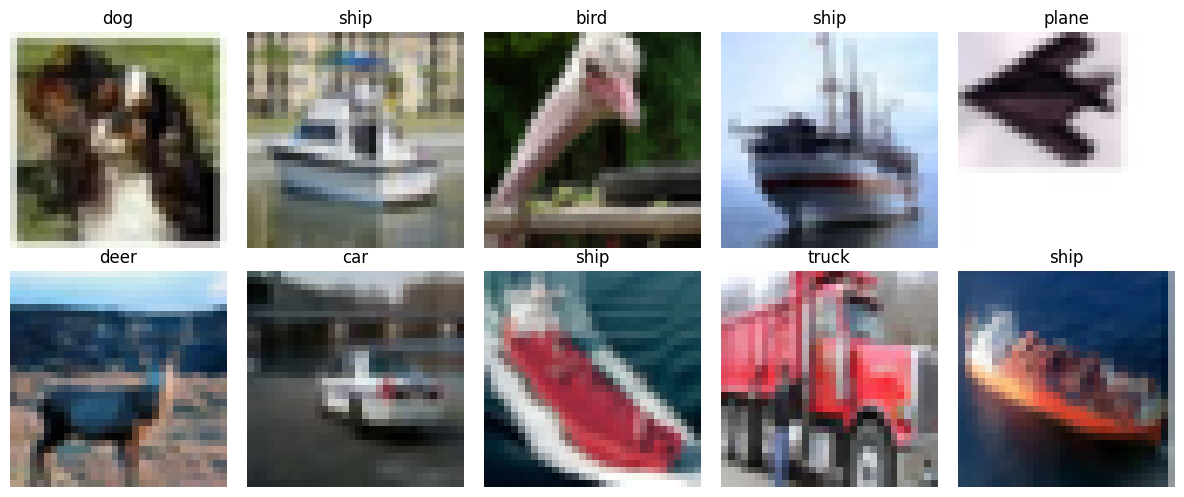

In [5]:
data = load_cifar10_subset(cfg)
print('Train:', data.train.images.shape, data.train.labels.shape)
print('Val  :', data.val.images.shape, data.val.labels.shape)
print('Test :', data.test.images.shape, data.test.labels.shape)
plot_examples(data.train.images, data.train.labels, data.class_names)

## The scaled dot-product attention

As you have learned from the lectures and the previous RNN lab, there exist several methods to implement the attention mechanism. In RNN, the attention mechanism generally uses the hidden states of the model to learn to focus the tokens (or elements) in a sequence. The transformer architecture uses the multi-head self-attention (MHSA) mechanism based the scaled dot-product attention. This new way of modeling attention was introduced in the landmark paper by Vaswani et al. in 2017 [Attention is all you need](https://arxiv.org/abs/1706.03762) and it is at the core of modern architectures such as [GPTs](https://en.wikipedia.org/wiki/GPT-3) and [BERT](https://en.wikipedia.org/wiki/BERT_(language_model)). 

In the following sections you will, step by step, take a closer look at the building blocks of the MHSA, starting an a visual intuition of how attention works.

### Back to the Future: Nadaraya-Watson kernel regression
Using a data retrieval analogy, imagine you are typing a query in a search engine. Under the hood, an algorithm compares your query with a database of keys and it returns the value corresponding to the key that best-matches your query. Thus, the attention can be viewed as a mapping between the query and the value using the similarity between the query and the keys. 

Consider the database $D = {(k_1, v_1), (k_2, v_2),\dots,(k_n, v_n)}$ made of $n$ tuples *(key, value)* pairs. Given a query $q$, we can formulate the attention over $D$ as: 
$$
\text{Attention}(q, D) = \sum_{i=1}^n \alpha(q,k_i)v_i,
$$
where $\alpha(q,k_i)$ are scalar values called attention weights. This operation, also referred to as *attention pooling*, is simply a linear combination of the values in the database using the *similarity* between the query and the keys. 

A simple, yet educative, example of how this concept works can be found in the kernel regression approach initially proposed by [Nadaraya](https://epubs.siam.org/doi/10.1137/1109020) and [Watson](https://www.jstor.org/stable/25049340) in 1964. In they formulation, the similarity metrics $\alpha(q,k_i)$ is chose to be a Gaussian kernel applied to the difference between the query and the keys:
$$
\alpha(q,k) = exp(-\frac{1}{2\sigma^2}||q - k ||^2),
$$
where the attention weight are then used to compute the output of a regressor or classifier as:
$$
f(q) = \sum_{i}v_i\frac{\alpha(q, k_i)}{\sum_{j}\alpha(q, k_i)}.
$$

In the following cell, we will visualize an example of scalar regression where the training samples are tuples of features and labels $(x_i, y_i)$, and the task is to predict the value at a new location. In this case $k$ are the features in out training sample, $v$ are the training labels and $q$ is the new location whose value we want to predict. 

In the following cell, we will define the dummy dataset you will work with and visualize how the choice of the parameters defining the Gaussian kernel ($\sigma$ in this case) affects the regressor prediction.

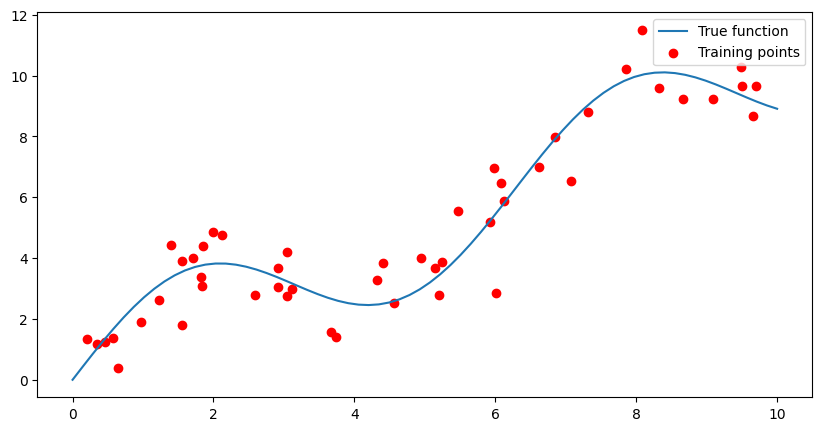

Training set: (50,), (50,)
Validation set: (70,), (70,)


In [6]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt

# define a random seed for reproducibility
seed = 42
np.random.seed(seed)

# define a function that creates a dummy dataset (sine wave with noise)
def dummy_dataset(x):
    return 2 * np.sin(x) + x

# create a dummy dataset: specify the number of training and validation samples, the range of x values and the noise level
nbr_train = 50
nbr_valid = 70
min_x, max_x = 0, 10

x_train = np.sort(np.random.uniform(min_x, max_x, nbr_train), 0)
y_train = dummy_dataset(x_train) + np.random.normal(0, 1, nbr_train)
x_val = np.linspace(min_x, max_x, nbr_valid)
y_val = dummy_dataset(x_val)

# plot the dataset
plt.figure(figsize=(10, 5))
plt.plot(x_val, y_val, label="True function")
plt.scatter(x_train, y_train, color="red", label="Training points")
plt.legend()
plt.show()

# print the shapes of the training and validation sets
print(f"Training set: {x_train.shape}, {y_train.shape}")
print(f"Validation set: {x_val.shape}, {y_val.shape}")

q: (70, 1), k: (50, 1), v: (50, 1)


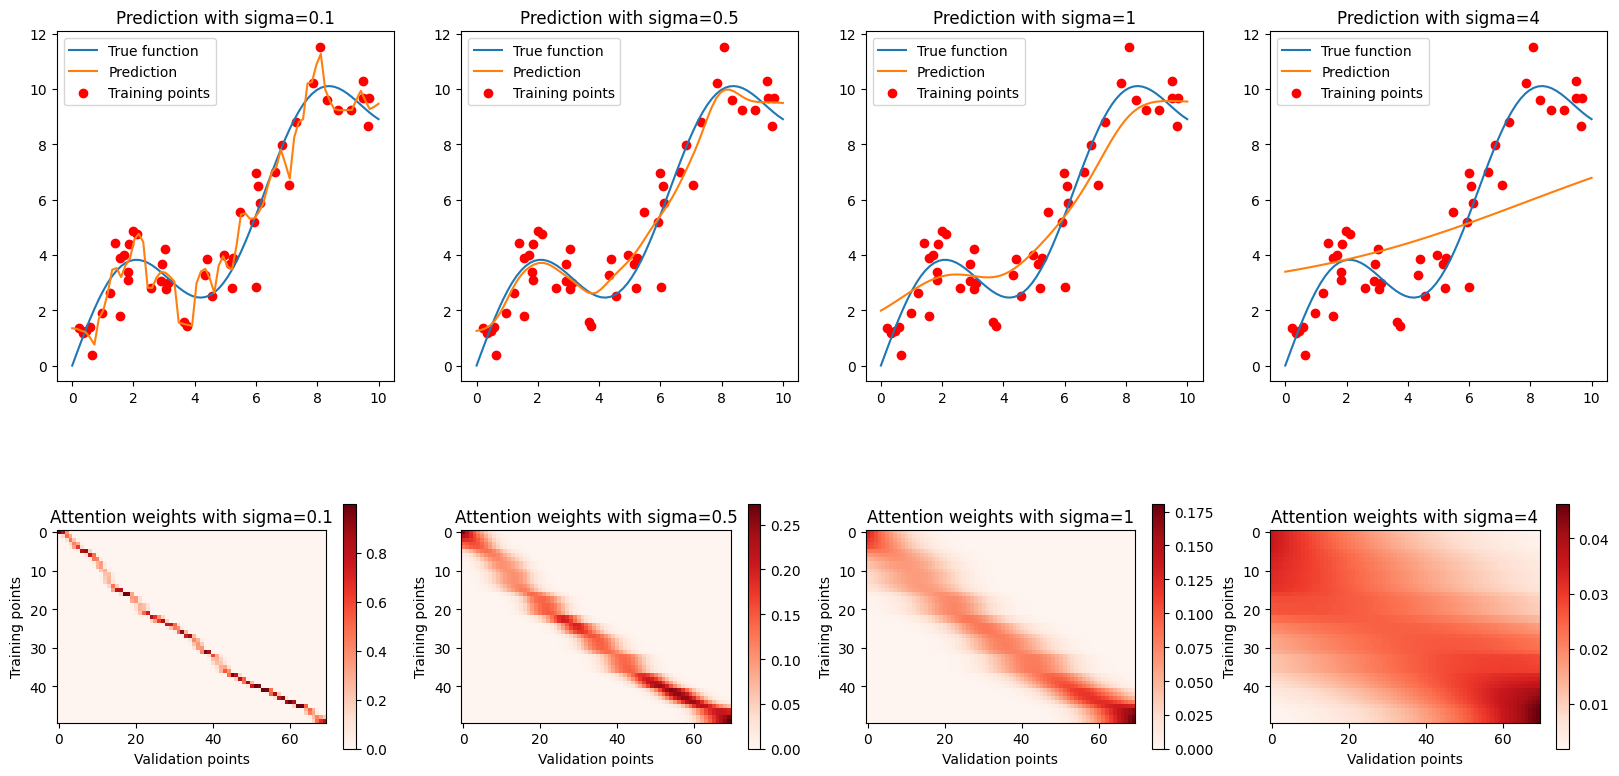

In [7]:
# Define the Gaussian regression kernel
def gaussian(x, sigma=1):
    return np.exp(-(x**2) / (2 * sigma**2))

# define the nadaraya_watson regressor function
def nadaraya_watson(q, k, v, kernel, sigma=1):
    # compute the distance matrix between the training and validation points
    distances = np.linalg.norm(k[:, np.newaxis, :] - q[np.newaxis, :, :], axis=2) # the element-wise difference between the queries and the keys
    # distances = k - q.T
    # Apply the kernel to the distances (across the rows)
    distances = kernel(distances, sigma)
    # Normalize the distances (across the rows) to obtain the attention weights
    attention_weights = distances / np.sum(distances, axis=0)
    # Use the attention weights to compute the prediction
    prediction = attention_weights.T @ v
    return prediction, attention_weights

# define the q, k and v using the dummy dataset (make them N -by- 1)
q = x_val[:, np.newaxis]
k = x_train[:, np.newaxis]
v = y_train[:, np.newaxis]
print(f"q: {q.shape}, k: {k.shape}, v: {v.shape}")

# plot the predictions and the attention weights for different values of sigma.
def plot_predictions(q, k, v, y_val, kernel, sigmas):
    if len(sigmas) == 1:
        fig, axs = plt.subplots(2, 1, figsize=(5, 10))
        axs = axs.reshape(2, 1)
    else:
        fig, axs = plt.subplots(2, len(sigmas), figsize=(20, 10))

    # loop through the sigma values
    for i, sigma in enumerate(sigmas):
        # compute the prediction and attention weights
        prediction, attention_weights = nadaraya_watson(q, k, v, kernel, sigma)
        # plot the prediction
        ax = axs[0, i]
        ax.plot(q, y_val, label="True function")
        ax.plot(q, prediction, label="Prediction")
        ax.scatter(k, v, color="red", label="Training points")
        ax.set_title(f"Prediction with sigma={sigma}")
        ax.legend()
        # plot the attention weights
        ax = axs[1, i]
        attention_plot = ax.imshow(attention_weights, cmap="Reds")
        ax.set_xlabel("Validation points")
        ax.set_ylabel("Training points")
        ax.set_title(f"Attention weights with sigma={sigma}")
        fig.colorbar(attention_plot, ax=ax, shrink=0.7)
    plt.show()

# define the sigma values to test
sigmas = [0.1, 0.5, 1, 4]
# plot the predictions
plot_predictions(q, k, v, y_val, gaussian, sigmas)

As you can see, the similarity kernel we use to attend to the distances greatly influences the prediction of the model. For sharper Gaussian kernels, the spikier the prediction while larger sigmas result in smoother prediction. Finding the best $\sigma$ in the case of a Gaussian kernel or a more suitable kernel among a [variety of kernels](https://en.wikipedia.org/wiki/Kernel_(statistics)) is time consuming. Thus, one can think of designing a model where the parameters of the kernel can be learned. Another way is to keep the similarity function the same but change the representations of the query, keys and values so that when compared thought the similarity function the output is different. As we will see soon, this last solution is what modern transformer architectures learn: they learn how to project $q$, $k$ and $v$ so that similarities are computed over different representations. 

#### **<span style="color:red">Questions</span>**
1. Looking at the examples in the Nadaraya - Watson regression, what are the benefits and drawbacks of this type of attention implementation? 

#### **<span style="color:green">Answers</span>**
1. The choice of the parameters has a great impact on the quality of the prediction. It is very easy to underfit or overfit the model. So, a great deal of effort is required to find the right parameters. On the other hand, its implementation seems quite simple and was able to learn the true function well, once the right value for sigma was found. Additionally, the plots of the attention weights aid in interpreting the model. This attention implememtation is able to efficiently learn the dependencies between all validation and training points.

### Scaled-dot product attention
The choice of a Gaussian regression kernel in the toy example was not by chance. In fact, one can prove that (see [here](https://d2l.ai/chapter_attention-mechanisms-and-transformers/attention-scoring-functions.html) for a more extensive description):

$$
\alpha(q,k_i) = -\frac{1}{2}||q - k_i||^2 = q^\top k_i -\frac{1}{2}||k_i||^2 -\frac{1}{2}||q||^2.
$$
The last term is similar for all the $k_i$, thus when normalizing this element disappears. In addition, as described [here](https://d2l.ai/chapter_attention-mechanisms-and-transformers/attention-scoring-functions.html), $||k_i||^2$ can also be removed in case the keys are themselves normalized (which is usually the case). This brings as close to the definition of the scaled dot-product attention by [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762), which is:
$$ 
\alpha(q, k_i) = \text{softmax}\left(\frac{q^\top k_i}{\sqrt{d}}\right)
$$
where $q\in\mathbb{R}^d$, $k_i \in \mathbb{R}^d$ and the scaling factor $\sqrt{d}$ ensures that the dot product variance is 1 regardless the query of key vector length $d$. Finally, expanding the formulation to the case where the attention is computed for $m$ queries and using it for attention pooling, we obtain:
$$Z = \text{softmax}\left(\frac{QK^\top}{\sqrt d}\right)V,$$

where $Q\in\mathbb{R}^{m\times d}$ is the matrix of all the query vectors, $K\in\mathbb{R}^{n\times d}$ and $v\in\mathbb{R}^{n\times d}$ is the matrix of all the keys and value vectors, and $Z\in\mathbb{R}^{m\times d}$ is the matrix containing all the weighted value vectors where weights are computed using the similarity between each query vector and the keys using the scaled-dot product attention.

In the next section we will implement the scaled dot-product attention.

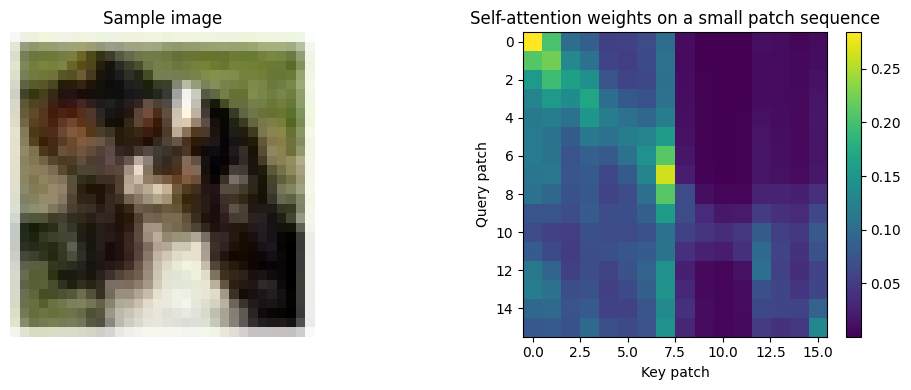

[1.         1.         1.         1.         0.99999994 0.99999994
 1.         1.         1.         1.         1.0000001  0.99999994
 1.         1.         1.         1.        ]


In [8]:
def softmax_numpy(x: np.ndarray, axis: int = -1) -> np.ndarray:
    # -----------------------------------------
    # === Your code here ===
    # Implement numerically stable softmax along the given axis.
    # -----------------------------------------

    #softmax: exp(xi)/sum(exp(xj))
    stable_x = np.subtract(x, np.max(x, axis = axis, keepdims=True))
    ex = np.exp(stable_x)

    return ex / np.sum(ex, axis=axis, keepdims=True)
    # ============================================


def scaled_dot_product_attention_numpy(q: np.ndarray, k: np.ndarray, v: np.ndarray):
    # -----------------------------------------
    # === Your code here ===
    # Compute Z = softmax(Q K^T / sqrt(d)) V
    # Return (output, attention_weights)
    # -----------------------------------------
    d = q.shape[1]
    attention_weights = softmax_numpy(q @ np.transpose(k) / np.sqrt(d))
    output = attention_weights @ v
    return output, attention_weights
    # ============================================


# Here the toy_token is a a random image in the dataset, and we take the first 16 patches and project them to 64 dimensions. We then add positional encoding to the tokens and compute the self-attention weights.
sample_image = data.train.images[:1]
sample_patches = extract_patches_numpy(sample_image, cfg.patch_size)
toy_tokens = sample_patches[0][:16, :32]
toy_tokens = toy_tokens + positional_encoding_numpy(toy_tokens.shape[0], toy_tokens.shape[1])
toy_output, toy_attention = scaled_dot_product_attention_numpy(toy_tokens, toy_tokens, toy_tokens)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: sample image
axes[0].imshow(sample_image[0])
axes[0].set_title('Sample image')
axes[0].axis('off')

# Right: self-attention weights
im = axes[1].imshow(toy_attention, cmap='viridis')
axes[1].set_title('Self-attention weights on a small patch sequence')
axes[1].set_xlabel('Key patch')
axes[1].set_ylabel('Query patch')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(np.sum(toy_attention, axis = -1))

### Multi-head attention

In practice, when given the same set of queries, keys, and values, we may want our model to integrate knowledge from different aspects using the same attention mechanism. For instance, it can be useful to capture dependencies at varying ranges within a sequence, such as short-range and long-range interactions. To achieve this, the attention mechanism can benefit from utilizing different representation subspaces for queries, keys, and values.

Instead of applying a single attention pooling operation, we can first transform the queries, keys, and values using independently learned linear projections. 
These projected versions are then processed through multiple attention pooling operations in parallel. 
The resulting outputs from each attention computation—referred to as **heads**—are then concatenated and passed through another learned linear projection to generate the final output. 
This architecture is known as multi-head attention [Vaswani et al., 2017](https://arxiv.org/abs/1706.03762), and you can see it visualized in the figure below. 
Note the multiple heads, each with its own set of linear projection $W_h^{q}, W_h^{k}$ and $W_h^{v}$ for queries, keys, and values, respectively. 

<p align="center">
    <img src="MHA.svg" alt="Multi-Head Attention"/>
</p>

#### **<span style="color:red">Questions</span>**
2. Describe the self-attention mechanism used in vision transformer architecture; how does it differ from that of the attention mechanism you implemented in the RNN lab?
3. What are the computational challenges related with the scaled dot-product attention? Is it more computationally demanding than that of the attention implemented in the RNN?
4. What are the advantages, from a computational perspective, of the scaled dot product compared to attention mechanism implemented in the RNN lab?
5. Can you think of a relation between the multi-head attention you just implemented and convolutional kernels in a CNN architecture? 

#### **<span style="color:green">Answers</span>**
2. The self-attention mechanism in vision transormer is very similar to the one used for texts or other types of data. The main difference is that each each key/value (or token) corresponds to a patch of the image. The remaining architecure remains unchanged. The attention mechanism implemented in the RNN computes attention sequentially. Therefore, the positional information of the words in the sentence is present, unlike in the tranformer architecture. Thus, a positional encoding of the words needs to be supplied.

3. The scaled product attention requires that each operation is performed for every single observation in the dataset, which is more computationally chanllenging than the attention in an RNN.

4. The scaled product can advantageously be run in parallel, unlike the attention mechanism in the RNN. This allows transformer to be run on GPUs and on multiple computers, allowing for more efficiency and training on larger datasets.

5. The multi-head attention mechaning is learning different kinds of relationships within the data, which can represent different phenomena or relationships. Similarly, each kernel in a CNN represents a different perspective or attribute of the image - light, gamma, contours, rotation, etc. - on which the model will learn and decide if they are relevant. So, in fact, one can say that they are similar, but conceptually operate in the opposite direction. While in a CNN the kernels/perspectives are first (randomly) generated and then the model learns the data, in a transformer it looks at the data and finds the relevant associations/perspectives.

### Transformer Encoder Layer

The transformer encoder layer is a fundamental building block of the transformer architecture. It consists of several key components that work together to process input sequences and generate meaningful representations. So far, we have implemented the multi-head attention mechanism, which allows the model to focus on different parts of the input sequence simultaneously. However, the full transformer encoder layer includes additional components that are crucial for its functionality:

1. **Multi-Head Attention**: This mechanism enables the model to attend to different positions of the input sequence and capture various aspects of the data. It consists of multiple attention heads, each focusing on different parts of the sequence.

2. **Layer Normalization**: Applied after the multi-head attention and feed-forward layers.

3. **Feed-Forward Neural Network**: This component consists of two linear transformations with a ReLU activation in between. It processes the output of the multi-head attention mechanism to generate more complex representations.

4. **Residual Connections**: These connections add the input of each sub-layer to its output.

5. **Dropout**: Applied to the outputs of the multi-head attention and feed-forward layers, dropout helps prevent overfitting by randomly setting a fraction of the input units to zero during training.

In the next step you will full transformer encoder layer (`TransformerBlock`) along with a patch encoder layer we can use in the full model (`PatchEmbedding`).

In [9]:
if not TF_AVAILABLE:
    raise RuntimeError(f'TensorFlow import failed, so the compact training path cannot run here: {TF_IMPORT_ERROR}')

class TransformerBlock(layers.Layer):
    def __init__(self, projection_dim: int, num_heads: int, mlp_dim: int, dropout_rate: float = 0.1):
        super().__init__()
        # -----------------------------------------
        # === Your code here ===
        # - Create a LayerNormalization layer (epsilon=1e-6) and store as self.norm1.
        # - Create a MultiHeadAttention layer with num_heads heads and
        #    key_dim = projection_dim // num_heads; pass dropout=dropout_rate. Store as self.attn.
        # - Create a second LayerNormalization layer (epsilon=1e-6) and store as self.norm2.
        # - Create the MLP as a keras.Sequential and store as self.mlp. It should contain:
        #      - Dense(mlp_dim, activation='gelu')
        #      - Dropout(dropout_rate)
        #      - Dense(projection_dim)
        #      - Dropout(dropout_rate)
        # -----------------------------------------
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim= projection_dim // num_heads, dropout=dropout_rate)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = keras.Sequential(
            [
                layers.Dense(mlp_dim, activation = 'gelu'),
                layers.Dropout(dropout_rate),
                layers.Dense(projection_dim),
                layers.Dropout(dropout_rate)
            ]
        )
        # ============================================

    def call(self, x, training=False, return_scores=False):
        # -----------------------------------------
        # === Your code here ===
        # 1. LayerNorm -> MultiHeadAttention (self-attention) -> residual
        # 2. LayerNorm -> MLP -> residual
        # If return_scores=True, also return attention weights.
        # -----------------------------------------
        norm_x = self.norm1(x)
        attention_output, attention_weights = self.attn(query = norm_x, value = norm_x, return_attention_scores=True, training=training)
        attention_residual = layers.Add()([attention_output, x])
        att_res_norm = self.norm2(attention_residual)
        mlp_output = self.mlp(att_res_norm)
        mlp_residual = layers.Add()([mlp_output, attention_residual ])

        if return_scores:
            return mlp_residual, attention_weights
        else:
            return mlp_residual
 
        # ============================================

# Run check on the TransformerBlock implementation
num_sequence_tokens = 42
toy_tokens = tf.random.normal((2, num_sequence_tokens, cfg.projection_dim))
toy_output, toy_attention_weights = TransformerBlock(cfg.projection_dim, cfg.num_heads, cfg.mlp_dim)(toy_tokens, return_scores=True)
assert toy_output.shape == toy_tokens.shape
assert toy_attention_weights.shape == (
    toy_tokens.shape[0],
    cfg.num_heads,
    toy_tokens.shape[1],
    toy_tokens.shape[1],
)
assert np.allclose(toy_attention_weights.numpy().sum(axis=-1), 1.0)

#### **<span style="color:red">Questions</span>**

6. In the MultiHeadAttention layer, key_dim is set to `projection_dim // num_heads` rather than `projection_dim`. Explain why. What would happen to the total number of parameters and the effective embedding dimension if you used `key_dim` = `projection_dim` instead?

#### **<span style="color:green">Answers</span>**

[Your answer here]

## Vision transformer

Now that you have implemented the core mechanism of a transformer architecture, we can apply it to for an image classification task. In the following cells, you will implement the remaining parts of a vision transformer (ViT) architecture and train a model for the classification of the **CIFAR10** dataset. 

As an overview, a vision transformer model is composed by four components:
1. **Patch extraction**: given the computational complexity on the (self) scaled-dot product attention is $O(n^2 d)$, applying the attention mechanism on the raw pixel values will be unfeasible for real world images. Thus, in the landmark paper that introduced the transformer architecture for computer vision tasks ([An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://arxiv.org/abs/2010.11929)), the authors split in image into squared patches (16 $\times$ 16 in the original implementation), which are flattened (or encoded) and used as input to the transformer architecture. 
2. **Patch embedding**: the scaled-dot product attention comes with the benefit of parallel computation but disregards the order of the input sequence. This is a problem when it comes to both vision and language modelling, where the order if the input sequence (*i.e.* the information regarding the closeness of pixels in an image) carries information. To address this issue, a **positional embedding** is added to each element in the sequence, providing information on both the position of an element in a sequence, and a feature within an element. (**NOTE!**: in this lab we will learnable positional encoding though a set of weights. The original implementation proposes a positional embedding based on sine & cosine function. These are not the only ways of implementing positional encoding, with modern architecture allowing for the positional encoding to be learned during training).
3. **Stack of transformer layers**: this is where the input image (patched and positional-encoded) traverses sequentially multiple transformer layers to obtain a representation that gathers information from all the image regions and that can be used for a downstream task (classification) in this case. 

**There is one problem though...** The the end of a sequence of transformer layers we obtain a new representation (based on the multi-head self attention mechanism) for each of the patches in the image. 
- **How do we use this for classification? Do we pick one of the patches as representative for the entire sequence? But then how to chose?**
- **Or do we apply a dense layer that combines all the sequences into one sequence?** 

What is done in the original implementation is to add a learnable sequence element, called the class token (`cls` token), which thought the transformer layers interacts with all the elements in the sequence. The `cls` token is then used as a representation of the entire input for the downstream task.

4. **Classification layer**: usually a dense layer receives as input the `cls` token and outputs logits (if working on a classification task).

In the following cells you will implement the `PatchEmbedding` layer which takes advantage of `tf.image.extract_patches` to extract image patches, and the full ViT model architecture, `TinyViT`. You will then train it on the CIFAR10 dataset. 

### `PatchEmbedding` layer

In [10]:
class PatchEmbedding(layers.Layer):
    def __init__(self, image_size: int, patch_size: int, projection_dim: int):
        super().__init__()
        self.image_size = image_size
        self.patch_size = patch_size
        # -----------------------------------------
        # === Your code here ===
        # - Compute and store num_patches
        # - Create a Dense layer to project each flattened patch to projection_dim
        #    and store it as self.projection.
        # -----------------------------------------
        self.num_patches = (image_size // patch_size) ** 2
        self.projection = layers.Dense(projection_dim)
        # ============================================

    def call(self, images, return_patches=False):
        # -----------------------------------------
        # === Your code here ===
        # Extract non-overlapping patches from images using tf.image.extract_patches,
        # reshape to (batch, num_patches, patch_dims), then apply self.projection.
        # Return the projected patch embeddings and the patches if return_patches is True.
        # -----------------------------------------

        patches = tf.image.extract_patches(images=images, sizes=[1, self.patch_size, self.patch_size, 1], strides=[1, self.patch_size, self.patch_size, 1], rates = [1,1,1,1], padding='VALID')
        patches_reshape = tf.reshape(patches, [tf.shape(images)[0], self.num_patches, tf.shape(patches)[-1]])
        projected_patches = self.projection(patches_reshape)

        if return_patches:
            return projected_patches, patches
        else:
            return projected_patches
        # ============================================

# For the PatchEmbedding
num_patches_per_side = cfg.image_size // cfg.patch_size
expected_num_patches = num_patches_per_side ** 2

np_patches = PatchEmbedding(cfg.image_size, cfg.patch_size, cfg.projection_dim)(data.train.images[:2])
assert np_patches.shape == (2, expected_num_patches, cfg.projection_dim)

### Run one image thought the PatchEmbedding and visualize the results

Patch embeddings shape: (1, 64, 64)
Extracted patches shape: (1, 8, 8, 48)


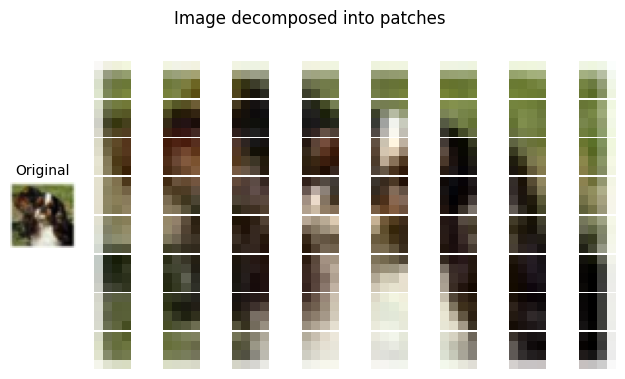

In [11]:
# Run one image thought the PatchEmbedding and visualize the results
## Define patch embedding layer and extract patches for one image
patch_embedding_layer = PatchEmbedding(cfg.image_size, cfg.patch_size, cfg.projection_dim)
patch_embeddings, patches = patch_embedding_layer(data.train.images[:1], return_patches=True)
print(f'Patch embeddings shape: {patch_embeddings.shape}')
print(f'Extracted patches shape: {patches.shape}')

# Show original image alongside patches arranged as a grid recomposing the image
grid_size = cfg.image_size // cfg.patch_size
patches_np = patches[0].numpy().reshape(grid_size, grid_size, cfg.patch_size, cfg.patch_size, 3)

fig = plt.figure(figsize=(8, 4))
gs = fig.add_gridspec(grid_size, grid_size + 1, hspace=0.05, wspace=0.05)

ax_orig = fig.add_subplot(gs[:, 0])
ax_orig.imshow(data.train.images[0])
ax_orig.set_title('Original', fontsize=10)
ax_orig.axis('off')

for row in range(grid_size):
    for col in range(grid_size):
        ax = fig.add_subplot(gs[row, col + 1])
        ax.imshow(patches_np[row, col])
        ax.axis('off')

fig.suptitle('Image decomposed into patches', y=1.01)
plt.show()

#### **<span style="color:red">Questions</span>**

7. Can you think of another way of encoding the patch information instead of linearly projecting them?
8. The transformer architecture is quite general and can be applied to images, text, or other input modalities. This flexibility comes at a cost, especially for computer vision tasks. Can you think of what this cost might be? (Hint: think about convolutional inductive biases.)

#### **<span style="color:green">Answers</span>**

[Your answers here]

### Putting all together - ViT model

Now you have implemented all the components of a ViT model, put all the components together.

In [12]:
class TinyViT(keras.Model):
    def __init__(self, config: LabConfig):
        super().__init__()
        self.config = config
        # -----------------------------------------
        # === Your code here ===
        # - Create a PatchEmbedding layer and store as self.patch_embed.
        # - Compute and store self.num_patches = (image_size // patch_size) ** 2.
        # - Create a trainable class token weight (self.cls_token) of shape
        #    (1, 1, projection_dim) via self.add_weight; use initializer='zeros'.
        # - Create a trainable positional embedding weight (self.pos_embed) of shape
        #    (1, num_patches + 1, projection_dim) via self.add_weight; use initializer='random_normal'.
        # - Create a list of TransformerBlock layers (self.blocks), one per transformer_layers.
        # - Create a LayerNormalization layer (epsilon=1e-6) and store as self.norm.
        # - Create a Dense classification head with num_classes outputs and store as self.head.
        # -----------------------------------------
        self.patch_embed = PatchEmbedding(config.image_size, config.patch_size, config.projection_dim)
        self.num_patches = (config.image_size // config.patch_size) ** 2
        self.cls_token = self.add_weight(shape=(1,1,config.projection_dim), initializer='zeros') # (1, 1, projection_dim)
        self.pos_embed = self.add_weight(shape=(1,self.num_patches + 1 ,config.projection_dim), initializer='random_normal') # (1, num_patches + 1, projection_dim)
        self.blocks = [TransformerBlock(config.projection_dim, config.num_heads, config.mlp_dim) for _ in range(config.transformer_layers)]
        self.norm = layers.LayerNormalization(epsilon=1e-6)
        self.head = layers.Dense(config.num_classes)

        # ============================================

    def call(self, images, training=False, return_attention=False):
        # -----------------------------------------
        # === Your code here ===
        # 1. Embed patches via self.patch_embed.
        patch_embeddings = self.patch_embed(images) # (batches, num_patches, projection_dim)
        # 2. Prepend cls_token and add positional embeddings.
        cls_tokens = keras.ops.broadcast_to(self.cls_token, (tf.shape(images)[0], 1, self.config.projection_dim))
        patch_embeddings = layers.Concatenate(axis=1)([cls_tokens, patch_embeddings]) + self.pos_embed
        # 3. Pass through each TransformerBlock.
        if return_attention:
            attention_maps = []
        for transformer in self.blocks:
            patch_embeddings, attention_map = transformer(patch_embeddings, training = training, return_scores=True)
            if return_attention:
                attention_maps.append(attention_map)
        # 4. Apply final LayerNorm and classification head on the cls token (index 0).
        patch_embeddings = self.norm(patch_embeddings)
        classification_head = self.head(patch_embeddings[:,0])
        # If return_attention=True, also return attention maps from each block.
        if return_attention:
            return classification_head, attention_maps
        else:
            return classification_head
        # -----------------------------------------
        # ============================================
    
# Run a basic check on the TinyViT implementation
model = TinyViT(cfg)
dummy_logits = model(tf.convert_to_tensor(data.train.images[:4]), training=False)
assert tuple(dummy_logits.shape) == (4, cfg.num_classes)
print('Basic tests passed.')

Basic tests passed.


#### **<span style="color:red">Questions</span>**

9. Check the original ViT paper and look for the number of model parameters given the same model configurations. Do we have the same number of trainable parameters? If not, why is this the case? (Hint: compare how projection matrices are defined in the paper and in this lab implementation.)

#### **<span style="color:green">Answers</span>**

[Your answers here]

## Model training

Implement or modify the training helper pipeline to include:

- optimizer and learning rate
- loss function and metric
- train/validation loop
- optional best-checkpoint logic

Use the default compact preset first, then optionally scale up.

#### **<span style="color:red">Questions</span>**

10. Compare the model performance for the ViT and the CNN model that you trained in the CNN lab. Which one obtained a higher classification accuracy?
11. There is one regularization method that we did not implement by default in this compact configuration that we did use in the CNN lab when it comes to data. What is it? Can this improve model performance and generalization?
12. Can you think how the output of a ViT model as implemented in this lab can be used for image segmentation?

#### **<span style="color:green">Answers</span>**

[Your answers here]

In [32]:
# Prepare the datasets
train_ds = make_tf_dataset(data.train, cfg.batch_size, training=True)
val_ds = make_tf_dataset(data.val, cfg.batch_size, training=False)
test_ds = make_tf_dataset(data.test, cfg.batch_size, training=False)

model = TinyViT(cfg)
model.compile(
    # -----------------------------------------
    # === Your code here ===
    # Define the optimizer, loss function, and metrics.
    # -----------------------------------------
    optimizer = keras.optimizers.Adam(learning_rate=0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
    # ============================================
)

history = model.fit(
    train_ds, 
    epochs = 50, 
    validation_data=val_ds,
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.1234 - loss: 2.6413 - val_accuracy: 0.1240 - val_loss: 2.2407
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.1428 - loss: 2.2861 - val_accuracy: 0.1780 - val_loss: 2.1457
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1605 - loss: 2.1990 - val_accuracy: 0.1960 - val_loss: 2.1145
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.1849 - loss: 2.1357 - val_accuracy: 0.2180 - val_loss: 2.0416
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.2304 - loss: 2.0545 - val_accuracy: 0.2320 - val_loss: 1.9783
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.2304 - loss: 2.0125 - val_accuracy: 0.2980 - val_loss: 1.9182
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2570 - loss: 1.9150 - val_accuracy: 0.2420 - val_loss: 1.9437
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.2517 - loss: 1.9337 - val_accuracy: 0.3200 - v

{'loss': 2.3930506706237793, 'compile_metrics': 0.37400001287460327}


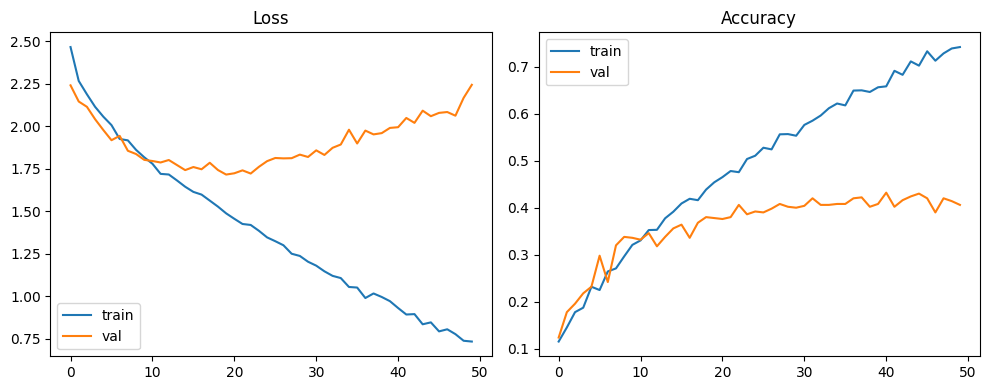

In [33]:
results = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, results)))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Prepare the datasets
train_ds = make_tf_dataset(data.train, cfg.batch_size, training=True)
val_ds = make_tf_dataset(data.val, cfg.batch_size, training=False)
test_ds = make_tf_dataset(data.test, cfg.batch_size, training=False)

model = TinyViT(cfg)
model.compile(
    # -----------------------------------------
    # === Your code here ===
    # Define the optimizer, loss function, and metrics.
    # -----------------------------------------
    optimizer = keras.optimizers.AdamW(learning_rate=0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'],
    # ============================================
)

history = model.fit(
    train_ds, 
    epochs = 50, 
    validation_data=val_ds,
    verbose=1
)

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.0994 - loss: 2.5881 - val_accuracy: 0.0880 - val_loss: 2.3064
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1101 - loss: 2.3403 - val_accuracy: 0.1400 - val_loss: 2.2357
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.1358 - loss: 2.2772 - val_accuracy: 0.1940 - val_loss: 2.1634
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1803 - loss: 2.2044 - val_accuracy: 0.1800 - val_loss: 2.1121
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.1727 - loss: 2.1723 - val_accuracy: 0.2280 - val_loss: 2.0642
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2127 - loss: 2.1308 - val_accuracy: 0.2340 - val_loss: 1.9935
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2249 - loss: 2.0568 - val_accuracy: 0.2560 - val_loss: 1.9767
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.2484 - loss: 1.9660 - val_accuracy: 0.2580 - v

{'loss': 2.2610034942626953, 'compile_metrics': 0.34599998593330383}


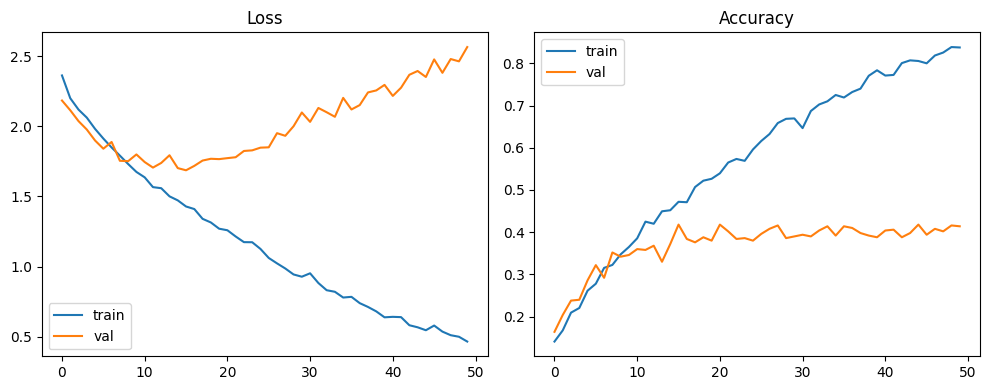

In [26]:
results = model.evaluate(test_ds, verbose=0)
print(dict(zip(model.metrics_names, results)))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

## Attention Visualization

We inspect where the class token attends in the first transformer block.

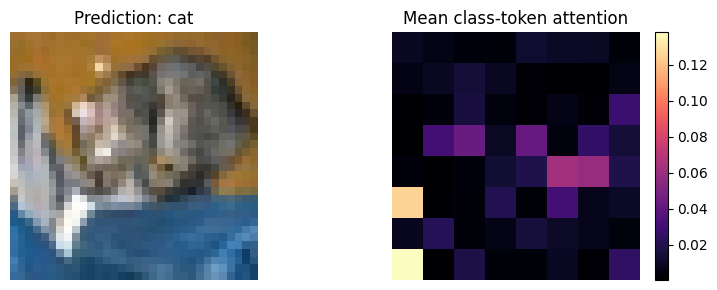

In [26]:
sample_batch = tf.convert_to_tensor(data.test.images[:1])
sample_logits, sample_attention = model(sample_batch, training=False, return_attention=True)
predicted_class = int(tf.argmax(sample_logits[0]).numpy())

first_block_attention = sample_attention[0][0].numpy()
cls_attention = first_block_attention[:, 0, 1:]
cls_attention = cls_attention.mean(axis=0)
attention_grid = cls_attention.reshape(num_patches_per_side, num_patches_per_side)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(data.test.images[0])
plt.title(f'Prediction: {data.class_names[predicted_class]}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(attention_grid, cmap='magma')
plt.title('Mean class-token attention')
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis('off')
plt.tight_layout()
plt.show()

## Carbon footprint

Compare the carbon footprint of training a Vision Transformer (ViT) model to that of a CNN model, as done in the CNN lab. Adjust the number of training and testing samples to match those used in the CNN lab, and set the batch size and number of epochs to the same values. After training the ViT model, measure the energy consumption (kWh) and CO₂ emissions (grams) and compare them to the values obtained for the CNN model.

NOTE! This cell will not work on Apple silicon hardware since CPU power usage requires `sudo` access to `/usr/bin/powermetrics` which is overkill for this lab.

In [ ]:
# run the experiment with carbontracker (skip on macOS)
is_mac = hasattr(os, "uname") and os.uname().sysname == "Darwin"

if is_mac:
    print("macOS detected: CarbonTracker will not work in this setup. Skipping tracker.")
else:
    tracker = CarbonTracker(epochs=cfg.epochs, components="all")
    tracker.epoch_start()

    # run the experiment
    history = model.fit(
        train_ds, 
        epochs = 50, 
        validation_data=val_ds,
        verbose=0
    )
    tracker.epoch_end()

CarbonTracker: The following components were found: CPU with device(s) cpu:0.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: Live carbon intensity could not be fetched at detected location: Lerum, Västra Götaland, SE. Defaulted to average carbon intensity for SE in 2023 of 40.69 gCO2/kWh. at detected location: Linköping, Östergötland, SE.
CarbonTracker: 
Predicted consumption for 25 epoch(s):
	Time:	0:20:23
	Energy:	0.017965570719 kWh
	CO2eq:	0.731106708601 g
	This is equivalent to:
	0.006800992638 km travelled by car


CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: WARNING - Failed to retrieve carbon intensity: Defaulting to average carbon intensity 40.694878 gCO2/kWh.
CarbonTracker: WARNING - ElectricityMaps API key not set. Will default to average carbon intensity.
CarbonTracker: W

#### **<span style="color:red">Questions</span>**
13. (ONLY if NOT Apple hardware): Compare the carbon footprint for training a ViT model with that of the CNN model of the CNN lab: which one had the highest footprint? Describe what is the reason of the difference. 

#### **<span style="color:green">Answers</span>**
[Your answer here]

## Optional Appendix: Pretrained ViT

This section is optional. It may require additional packages and model downloads, so it is not part of the main CPU-safe path.

In [11]:
OPTIONAL_PRETRAINED = False

if OPTIONAL_PRETRAINED:
    from transformers import AutoImageProcessor, ViTForImageClassification
    import torch

    processor = AutoImageProcessor.from_pretrained('google/vit-base-patch16-224')
    pretrained_model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

    image = (data.test.images[0] * 255).astype('uint8')
    inputs = processor(images=image, return_tensors='pt')
    with torch.no_grad():
        outputs = pretrained_model(**inputs)
    print('Predicted class index:', int(outputs.logits.argmax(dim=-1)))
else:
    print('Optional appendix skipped. Set OPTIONAL_PRETRAINED = True to enable it.')

Optional appendix skipped. Set OPTIONAL_PRETRAINED = True to enable it.


## Transformers for text summarization

In this next section you can play around with a sequence-to-sequence (Seq2Seq) transformer model for text summarization. As before, we will use a pre-trained model from the `transformer` library. In this example we will use the [T5 model](https://arxiv.org/abs/1910.10683) which can be prompted to perform several NLP tasks, such as summarization. 

For short text, you can input the text directly as a variable. For longer texts, copy it into a .txt file, which will be then loaded and fed to the model. You will see that the longer the input text, the better the answer.

In [ ]:
# Load both the tokenizer and the model
from transformers import T5Tokenizer, TFT5ForConditionalGeneration
tokenizer = T5Tokenizer.from_pretrained("t5-small")
model = TFT5ForConditionalGeneration.from_pretrained("t5-small")

In [ ]:
# Load .txt or input text for summary manually

# Load the text file
with open('NLP_text.txt', 'r') as file:
    text = file.read()

# Or input text manually
# text = 'Some text to summarize'

# get the number of words in the text
nbr_words = len(text.split())
# set the maximum length of the model output to 50% of the number of original words
max_length = int(0.5 * nbr_words)
# set the minimum number of output words to 10
min_length = 10

# print the number of words in the text
print(f"Number of words in the text: {nbr_words}")

In [ ]:
# specify the task that the model should perform
task = 'summarize'
# create the input string for the model and pass it thought the tokenizer
input_ids = tokenizer(f"{task} : {text}", return_tensors="tf").input_ids
# generate model outputs
outputs = model.generate(input_ids, max_length=max_length, min_length=min_length, do_sample=True)

# print model output
print(tokenizer.decode(outputs[0], skip_special_tokens=True))